In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
df_statistics = pd.read_csv("../../data/processed_data/dataset_information/genomes_info_with_partitions.csv")
df_statistics = df_statistics.rename(columns={"Unnamed: 0":"accession"})

# Plots of coding percentage

/var/folders/2g/7qq8263d1bd2j1p8_1gc7w3h0000gn/T/ipykernel_97576/355497070.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([df_statistics[df_statistics['partition'] == p]['coding_percentage']


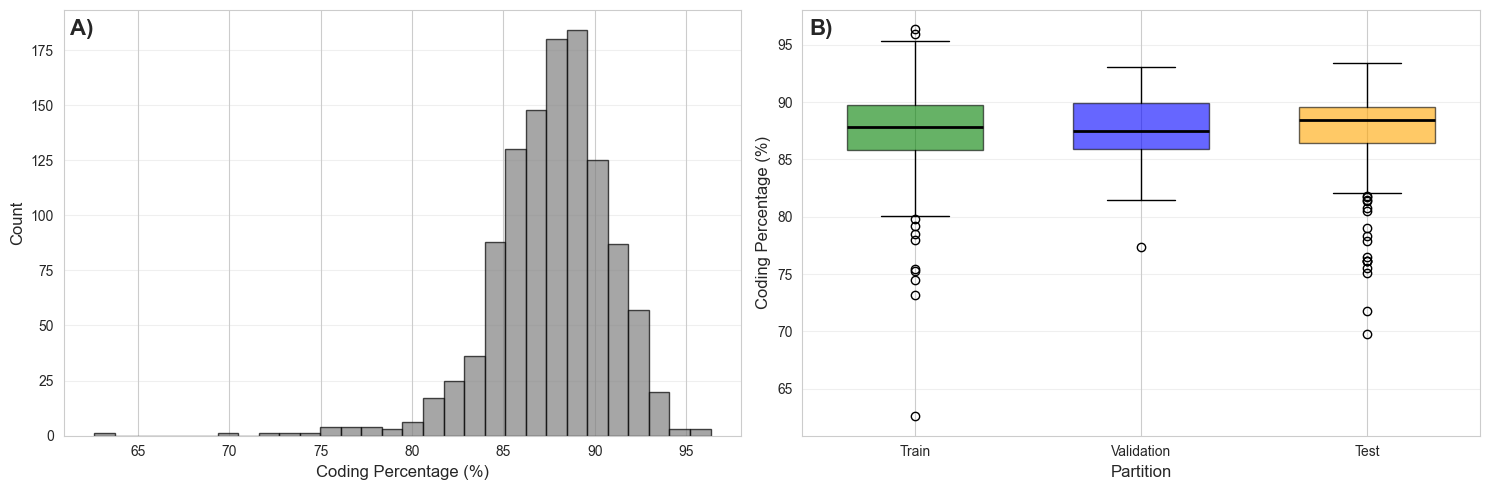


Summary Statistics by Partition:
           count       mean       std    min     25%    50%     75%    max
partition                                                                 
test       219.0  87.595753  3.816816  69.77  86.465  88.43  89.575  93.41
train      813.0  87.710037  3.077385  62.60  85.810  87.79  89.710  96.34
val         97.0  87.446701  3.025209  77.36  85.920  87.51  89.900  93.05


In [ ]:
# Set style
sns.set_style("whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Overall histogram
axes[0].hist(df_statistics['coding_percentage'], bins=30, color='gray', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Coding Percentage (%)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
#axes[0].set_title('Overall Distribution of Coding Percentage', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].text(0.01, 0.98, 'A)', transform=axes[0].transAxes, fontsize=16, fontweight='bold', va='top')

colors = {'train': 'green', 'val': 'blue', 'test': 'orange'}

# 2. Boxplot by partition
partition_order = ['train', 'val', 'test']
partition_labels = ['Train', 'Validation', 'Test']
box_colors = [colors.get(p, 'gray') for p in partition_order]

bp = axes[1].boxplot([df_statistics[df_statistics['partition'] == p]['coding_percentage']
                      for p in partition_order],
                     labels=partition_labels,
                     patch_artist=True,
                     widths=0.6)

# Color the boxes
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Make median lines black
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

axes[1].set_xlabel('Partition', fontsize=12)
axes[1].set_ylabel('Coding Percentage (%)', fontsize=12)
#axes[1].set_title('Coding Percentage Distribution by Partition', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].text(0.01, 0.98, 'B)', transform=axes[1].transAxes, fontsize=16, fontweight='bold', va='top')

plt.tight_layout()
plt.show()

# Optional: Print summary statistics by partition
print("\nSummary Statistics by Partition:")
print(df_statistics.groupby('partition')['coding_percentage'].describe())

# Plot genome length

/var/folders/2g/7qq8263d1bd2j1p8_1gc7w3h0000gn/T/ipykernel_97576/2664541123.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([df_statistics[df_statistics['partition'] == p]['genome_length_kb']


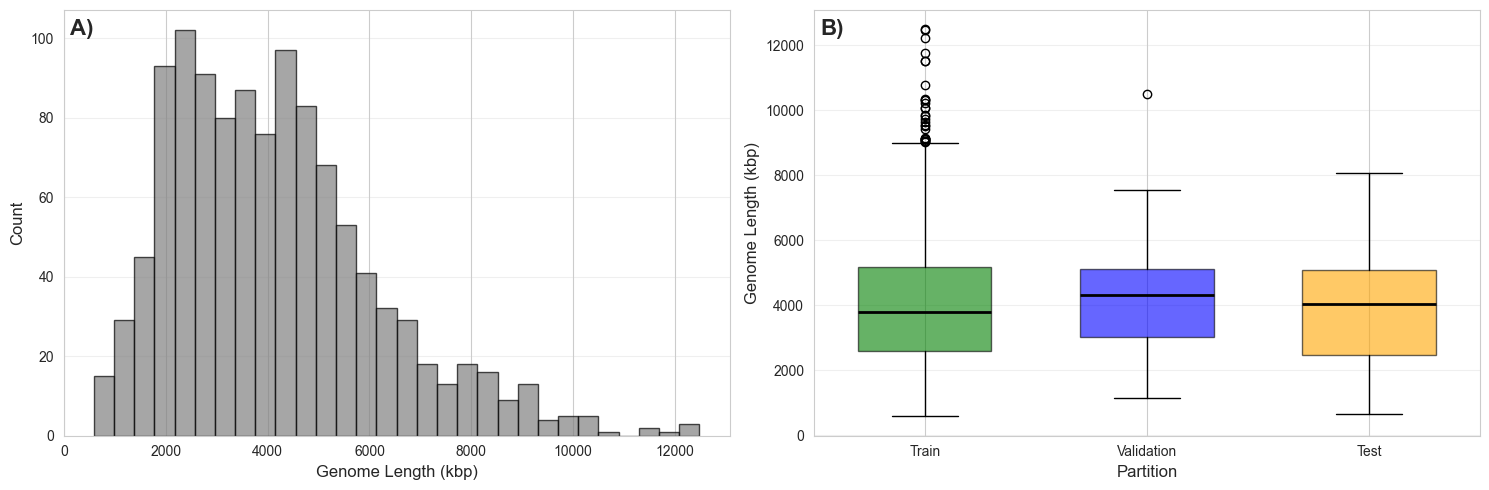


Summary Statistics by Partition:
           count         mean          std     min     25%     50%     75%  \
partition                                                                    
test       219.0  3895.378995  1666.322790   641.0  2473.0  4042.0  5080.5   
train      813.0  4215.261993  2156.957274   580.0  2600.0  3788.0  5163.0   
val         97.0  4081.865979  1644.985028  1130.0  3006.0  4324.0  5107.0   

               max  
partition           
test        8080.0  
train      12489.0  
val        10486.0  


In [ ]:
# Set style
sns.set_style("whitegrid")

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Overall histogram
axes[0].hist(df_statistics['genome_length_kb'], bins=30, color='gray', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Genome Length (kbp)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
#axes[0].set_title('Overall Distribution of Genome Length', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].text(0.01, 0.98, 'A)', transform=axes[0].transAxes, fontsize=16, fontweight='bold', va='top')

colors = {'train': 'green', 'val': 'blue', 'test': 'orange'}

# 2. Boxplot by partition
partition_order = ['train', 'val', 'test']
partition_labels = ['Train', 'Validation', 'Test']
box_colors = [colors.get(p, 'gray') for p in partition_order]

bp = axes[1].boxplot([df_statistics[df_statistics['partition'] == p]['genome_length_kb']
                      for p in partition_order],
                     labels=partition_labels,
                     patch_artist=True,
                     widths=0.6)

# Color the boxes
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Make median lines black
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

axes[1].set_xlabel('Partition', fontsize=12)
axes[1].set_ylabel('Genome Length (kbp)', fontsize=12)
#axes[1].set_title('Genome Length Distribution by Partition', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].text(0.01, 0.98, 'B)', transform=axes[1].transAxes, fontsize=16, fontweight='bold', va='top')

plt.tight_layout()
plt.show()

# Optional: Print summary statistics by partition
print("\nSummary Statistics by Partition:")
print(df_statistics.groupby('partition')['genome_length_kb'].describe())